In [1]:
import pandas as pd
import numpy as np
import scipy.stats
import scipy.signal as scisig

In [2]:
df_1 = pd.read_csv("../Dataset/S2_chest_data.csv")
print("loaded df_1")
df_2 = pd.read_csv("../Dataset/S3_chest_data.csv")
print("loaded df_2")
df_3 = pd.read_csv("../Dataset/S9_chest_data.csv")
print("loaded df_3")

loaded df_1
loaded df_2
loaded df_3


In [4]:

# ── Constants ──────────────────────────────────────────────────────────────
FS = 700  # Chest device sampling frequency (Hz)
WINDOW_IN_SECONDS = 30
WINDOW_LEN = FS * WINDOW_IN_SECONDS  # 21000 samples per window

label_dict = {0: 'baseline', 1: 'stress', 2: 'amusement'}

SENSOR_COLS = ['ACC_X', 'ACC_Y', 'ACC_Z', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']

# ── Helper: slope of a signal ──────────────────────────────────────────────
def get_slope(series):
    series = series.dropna().values
    return scipy.stats.linregress(np.arange(len(series)), series)[0]

# ── Helper: net acceleration magnitude ────────────────────────────────────
def get_net_accel(w):
    return np.sqrt(w['ACC_X']**2 + w['ACC_Y']**2 + w['ACC_Z']**2)

# ── Helper: dominant frequency via periodogram ─────────────────────────────
def get_peak_freq(x, fs=FS):
    f, Pxx = scisig.periodogram(x.dropna().values, fs=fs)
    return f[np.argmax(Pxx)]

# ── Core: extract features from one 30s window ────────────────────────────
def extract_window_features(w, label):
    feats = {}

    # Per-sensor stats
    for col in SENSOR_COLS:
        sig = w[col].dropna().values
        feats[f'{col}_mean'] = np.mean(sig)
        feats[f'{col}_std']  = np.std(sig)
        feats[f'{col}_min']  = np.min(sig)
        feats[f'{col}_max']  = np.max(sig)

    # Net acceleration stats
    net_acc = get_net_accel(w).values
    feats['net_acc_mean'] = np.mean(net_acc)
    feats['net_acc_std']  = np.std(net_acc)
    feats['net_acc_min']  = np.min(net_acc)
    feats['net_acc_max']  = np.max(net_acc)

    # Extra features
    feats['ECG_peak_freq']  = get_peak_freq(w['ECG'])
    feats['Resp_peak_freq'] = get_peak_freq(w['Resp'])
    feats['Temp_slope']     = get_slope(w['Temp'])
    feats['EDA_slope']      = get_slope(w['EDA'])

    feats['label'] = label
    return feats

# ── Core: slide windows over one subject's dataframe ──────────────────────
def get_samples_from_df(df):
    all_samples = []

    # Process each label group separately
    for label_val, group in df.groupby('Label'):
        group = group.reset_index(drop=True)
        n_windows = len(group) // WINDOW_LEN

        for i in range(n_windows):
            w = group.iloc[WINDOW_LEN * i : WINDOW_LEN * (i + 1)]
            feats = extract_window_features(w, label=label_val)
            all_samples.append(feats)

    return pd.DataFrame(all_samples)

# ── Run for all subjects ───────────────────────────────────────────────────
subject_dfs  = [df_1, df_2, df_3]
subject_ids  = [2, 3, 9]

all_subject_features = []

for sid, df in zip(subject_ids, subject_dfs):
    print(f"Processing S{sid}...")
    feats_df = get_samples_from_df(df)
    feats_df['subject'] = sid
    all_subject_features.append(feats_df)
    print(f"  S{sid}: {len(feats_df)} windows extracted")

# ── Combine & save ─────────────────────────────────────────────────────────
final_df = pd.concat(all_subject_features, ignore_index=True)
print(f"\nFinal dataset shape: {final_df.shape}")
print(f"Label distribution:\n{final_df['label'].value_counts()}")

final_df.to_csv("../Dataset/preprocessed_data.csv", index=False)
print("\nSaved to ../Dataset/preprocessed_data.csv")

Processing S2...
  S2: 201 windows extracted
Processing S3...
  S3: 214 windows extracted
Processing S9...
  S9: 172 windows extracted

Final dataset shape: (587, 42)
Label distribution:
label
0    281
1    115
4     77
2     62
3     36
6      6
7      6
5      4
Name: count, dtype: int64

Saved to ../Dataset/preprocessed_data.csv


In [41]:
df = pd.read_csv("../Dataset/preprocessed_data.csv")

In [42]:
df.head()

,ACC_X_mean,ACC_X_std,ACC_X_min,ACC_X_max,ACC_Y_mean,ACC_Y_std,ACC_Y_min,ACC_Y_max,ACC_Z_mean,ACC_Z_std,...,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,ECG_peak_freq,Resp_peak_freq,Temp_slope,EDA_slope,label,subject
0,0.872800,0.024465,0.5070,1.1758,-0.132889,0.031347,-0.4014,0.1010,-0.284486,0.047498,...,0.929273,0.025727,0.522995,1.506039,2.200000,0.433333,-0.000012,-0.000033,0,2
1,0.875788,0.059040,0.4826,1.2712,-0.120982,0.078589,-0.4616,0.1268,-0.245599,0.127737,...,0.929947,0.056012,0.496726,1.303793,2.600000,0.066667,-0.000037,-0.000015,0,2
2,0.861583,0.021205,0.7454,1.1624,-0.156330,0.020616,-0.2042,-0.1002,-0.316530,0.031280,...,0.931918,0.018373,0.785213,1.185841,1.300000,0.100000,0.000004,0.000032,0,2
3,0.862690,0.009803,0.7906,0.9224,-0.181321,0.022755,-0.2394,-0.1370,-0.306185,0.014533,...,0.933610,0.007607,0.882272,0.981359,2.466667,0.366667,0.000003,-0.000026,0,2
4,0.857272,0.006321,0.8050,0.9246,-0.188318,0.022537,-0.2520,-0.1382,-0.320673,0.011200,...,0.934800,0.005797,0.882175,0.996625,1.200000,0.400000,-0.000011,-0.000036,0,2


In [50]:
df.shape

(290, 42)

In [43]:
df.columns

Index(['ACC_X_mean', 'ACC_X_std', 'ACC_X_min', 'ACC_X_max', 'ACC_Y_mean',
       'ACC_Y_std', 'ACC_Y_min', 'ACC_Y_max', 'ACC_Z_mean', 'ACC_Z_std',
       'ACC_Z_min', 'ACC_Z_max', 'ECG_mean', 'ECG_std', 'ECG_min', 'ECG_max',
       'EMG_mean', 'EMG_std', 'EMG_min', 'EMG_max', 'EDA_mean', 'EDA_std',
       'EDA_min', 'EDA_max', 'Temp_mean', 'Temp_std', 'Temp_min', 'Temp_max',
       'Resp_mean', 'Resp_std', 'Resp_min', 'Resp_max', 'net_acc_mean',
       'net_acc_std', 'net_acc_min', 'net_acc_max', 'ECG_peak_freq',
       'Resp_peak_freq', 'Temp_slope', 'EDA_slope', 'label', 'subject'],
      dtype='str')

In [44]:
df["label"].value_counts()

label
0    281
1    115
4     77
2     62
3     36
6      6
7      6
5      4
Name: count, dtype: int64

In [46]:
accept_label = [1, 2, 3, 4]
df = df[df["label"].isin(accept_label)]

In [48]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["label"] = df["label"].apply(apply_target)

In [49]:
df["label"].value_counts()

label
0    228
1     62
Name: count, dtype: int64

In [51]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [53]:
from sklearn.utils import resample

# majority class
low_stress = train[train["label"] == 0]

# minority class
high_stress = train[train["label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

train = pd.concat([low_downsampled, high_stress]).sample(frac=1)

train['label'].value_counts()

label
0    54
1    54
Name: count, dtype: int64

In [55]:
x_train = train.drop("label", axis=1)
y_train = train["label"]

y_test = test["label"]
x_test = test.drop("label", axis=1)

In [56]:
from xgboost import XGBClassifier, plot_importance, plot_tree

model = XGBClassifier(
    n_estimators      = 100,       # number of boosting rounds
    max_depth         = 3,         # depth of each tree
    learning_rate     = 0.2,       # shrinks contribution of each tree (eta)
    subsample         = 0.7,       # fraction of samples per tree
    colsample_bytree  = 0.7,       # fraction of features per tree
    gamma             = 0,         # min loss reduction to split a node
    reg_alpha         = 0,         # L1 regularization
    reg_lambda        = 1,         # L2 regularization
    eval_metric       = "logloss",  # "logloss" for binary
    objective        = "binary:logistic",  # ← add this for binary (0/1)
    random_state      = 42,
    n_jobs            = -1
)



model.fit(
    x_train, y_train,
    eval_set              = [(x_train, y_train), (x_test, y_test)],
    verbose               = 10        # print every 10 rounds
)

[0]	validation_0-logloss:0.56047	validation_1-logloss:0.57398
[10]	validation_0-logloss:0.16316	validation_1-logloss:0.29902
[20]	validation_0-logloss:0.08180	validation_1-logloss:0.24531
[30]	validation_0-logloss:0.05501	validation_1-logloss:0.23886
[40]	validation_0-logloss:0.04285	validation_1-logloss:0.24995
[50]	validation_0-logloss:0.03789	validation_1-logloss:0.24973
[60]	validation_0-logloss:0.03361	validation_1-logloss:0.24787
[70]	validation_0-logloss:0.03180	validation_1-logloss:0.26499
[80]	validation_0-logloss:0.03019	validation_1-logloss:0.25273
[90]	validation_0-logloss:0.02986	validation_1-logloss:0.25121
[99]	validation_0-logloss:0.02862	validation_1-logloss:0.25486


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [58]:
X_test = test.drop("label", axis=1)

In [59]:
y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, classification_report
y_test = test["label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.896551724137931
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        50
           1       0.57      1.00      0.73         8

    accuracy                           0.90        58
   macro avg       0.79      0.94      0.83        58
weighted avg       0.94      0.90      0.91        58



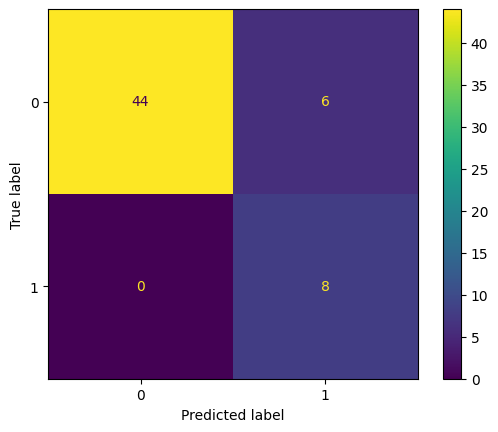

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

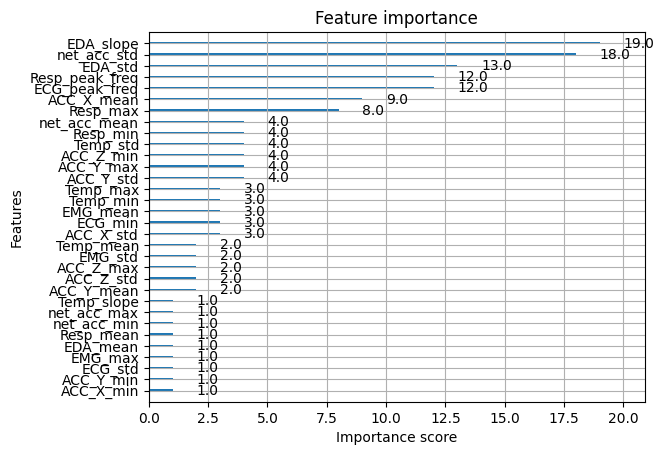

In [63]:
from xgboost import plot_importance
plot_importance(model)

In [64]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=train.drop("label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [67]:
explanation = explainer.explain_instance(
    data_row=x_test.iloc[0].values,   # <-- FIX
    predict_fn=model.predict_proba,
    num_features=100
)


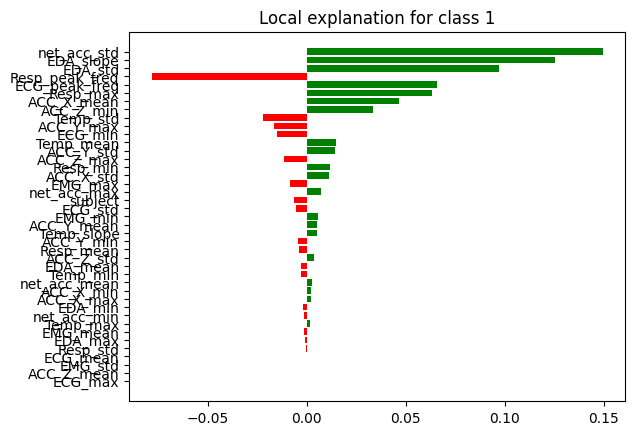

In [68]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

In [69]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)

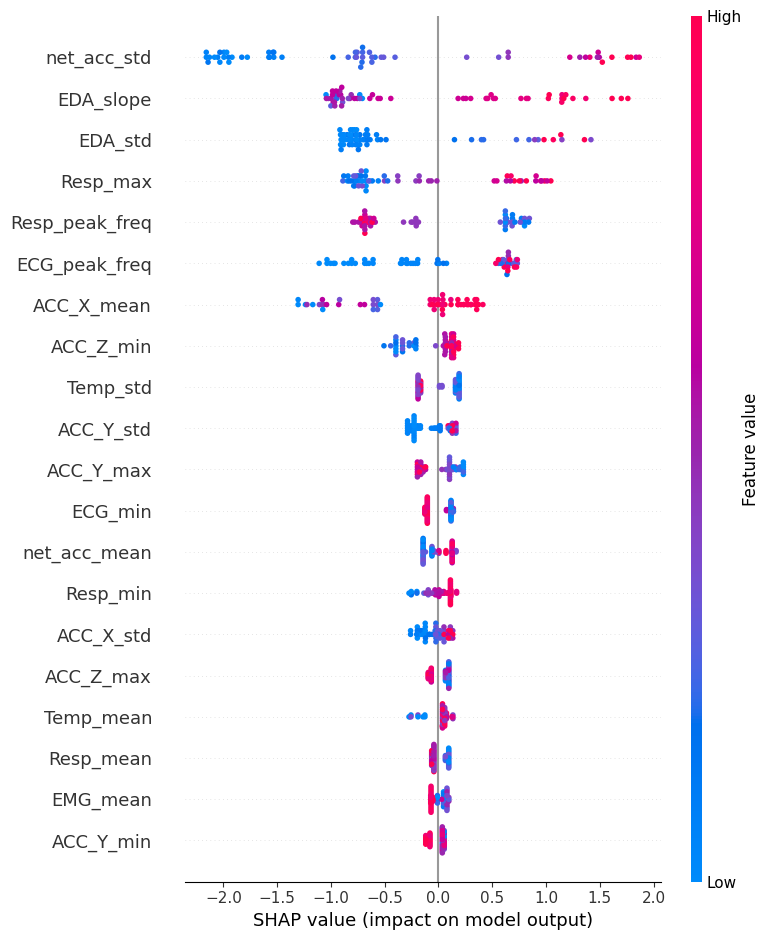

In [70]:
shap.summary_plot(shap_values, x_test)